In [9]:

import pandas as pd

# Cargar Excel
df = pd.read_excel("/Online Retail.xlsx")


df.head()

# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
# Eliminar nulos
df = df.dropna()

# Eliminar devoluciones
df = df[df['Quantity'] > 0]

# Crear total de venta
df['Total'] = df['Quantity'] * df['UnitPrice']

In [12]:
print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Total  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
(397924, 9)


Que hice acá?


✔ Elimine nulos

Porque pueden distorsionar el análisis.

✔ Elimine devoluciones

Quantity < 0 suele significar productos devueltos/cancelaciones.

✔ Creacion Total

Para analizar ingresos reales.

# ANÁLISIS CLAVE
🔥 1. TOP PRODUCTOS

In [14]:
top_productos = (
    df.groupby('Description')['Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_productos)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Total, dtype: float64




 TOP PRODUCTOS MÁS VENDIDOS

 1. PAPER CRAFT, LITTLE BIRDIE

 Kit o decoración artesanal de papel con diseño de pajarito.


2. REGENCY CAKESTAND 3 TIER

 Soporte de tortas de 3 niveles estilo elegante/vintage.

3. WHITE HANGING HEART T-LIGHT HOLDER

Porta vela decorativo colgante en forma de corazón.



4. JUMBO BAG RED RETROSPOT

Bolsa grande reutilizable con diseño retro rojo.

5. MEDIUM CERAMIC TOP STORAGE JAR

 Frasco de almacenamiento con tapa cerámica.


6. POSTAGE

Costos de envío/postal.

el dataset registra gastos de envío
o ventas internacionales


7. PARTY BUNTING

 Guirnaldas decorativas para fiestas.




8. ASSORTED COLOUR BIRD ORNAMENT

 Adornos decorativos de pájaros de colores.



 9. Manual
 Esto tampoco es un producto real.

 Suele representar:

ajustes manuales
correcciones
cargas administrativas



10. RABBIT NIGHT LIGHT

 Luz nocturna decorativa con forma de conejo.




 Eliminá:

POSTAGE

Manual

Porque no son productos reales.

In [16]:
df = df[~df['Description'].isin(['POSTAGE', 'Manual'])]

In [17]:
top_productos = (
    df.groupby('Description')['Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# 👥 2. TOP CLIENTES

In [19]:
top_clientes = (
    df.groupby('CustomerID')['Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_clientes)

CustomerID
14646.0    279138.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    140450.72
12415.0    124564.53
14156.0    117379.63
17511.0     91062.38
12346.0     77183.60
16029.0     72882.09
Name: Total, dtype: float64


# 📅  VENTAS POR MES

In [20]:
# Convertir fecha
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Crear columna mes
df['Mes'] = df['InvoiceDate'].dt.to_period('M')

# Agrupar ventas
ventas_mes = df.groupby('Mes')['Total'].sum()

print(ventas_mes)

Mes
2010-12     568055.720
2011-01     564241.640
2011-02     443546.020
2011-03     585262.850
2011-04     455681.911
2011-05     660932.900
2011-06     654932.560
2011-07     593231.901
2011-08     637168.410
2011-09     943512.642
2011-10    1009781.660
2011-11    1148481.110
2011-12     514994.690
Freq: M, Name: Total, dtype: float64


# 📈 GRÁFICOS

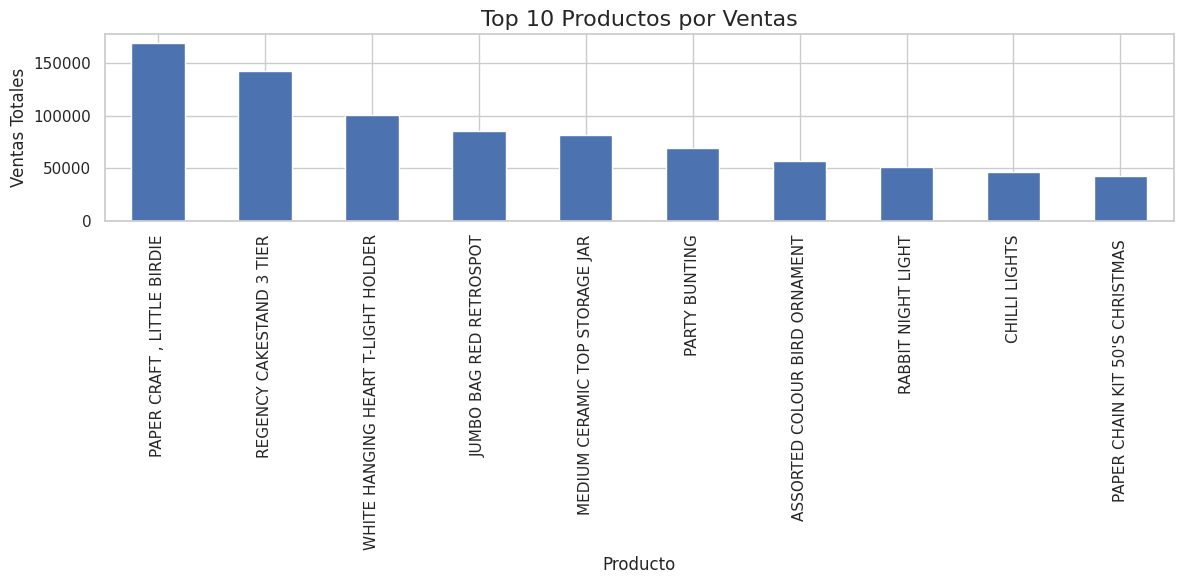

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

top_productos.plot(kind='bar')

plt.title("Top 10 Productos por Ventas", fontsize=16)
plt.xlabel("Producto")
plt.ylabel("Ventas Totales")

plt.tight_layout()

plt.savefig("top_productos.png", dpi=300, bbox_inches='tight')

plt.show()

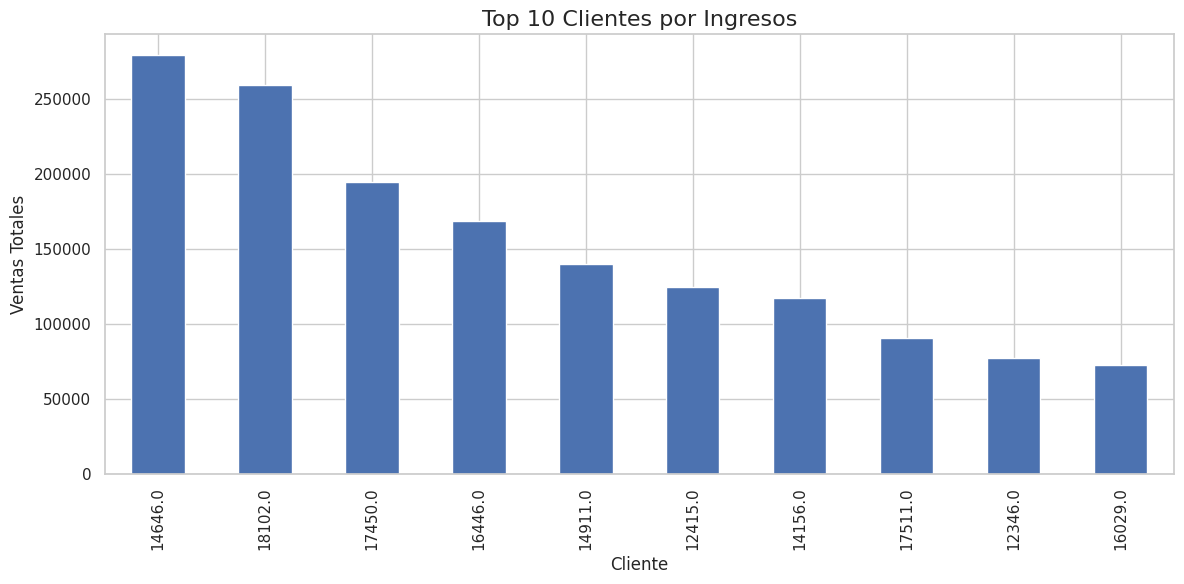

In [22]:
plt.figure(figsize=(12,6))

top_clientes.plot(kind='bar')

plt.title("Top 10 Clientes por Ingresos", fontsize=16)
plt.xlabel("Cliente")
plt.ylabel("Ventas Totales")

plt.tight_layout()

plt.savefig("top_clientes.png", dpi=300, bbox_inches='tight')

plt.show()

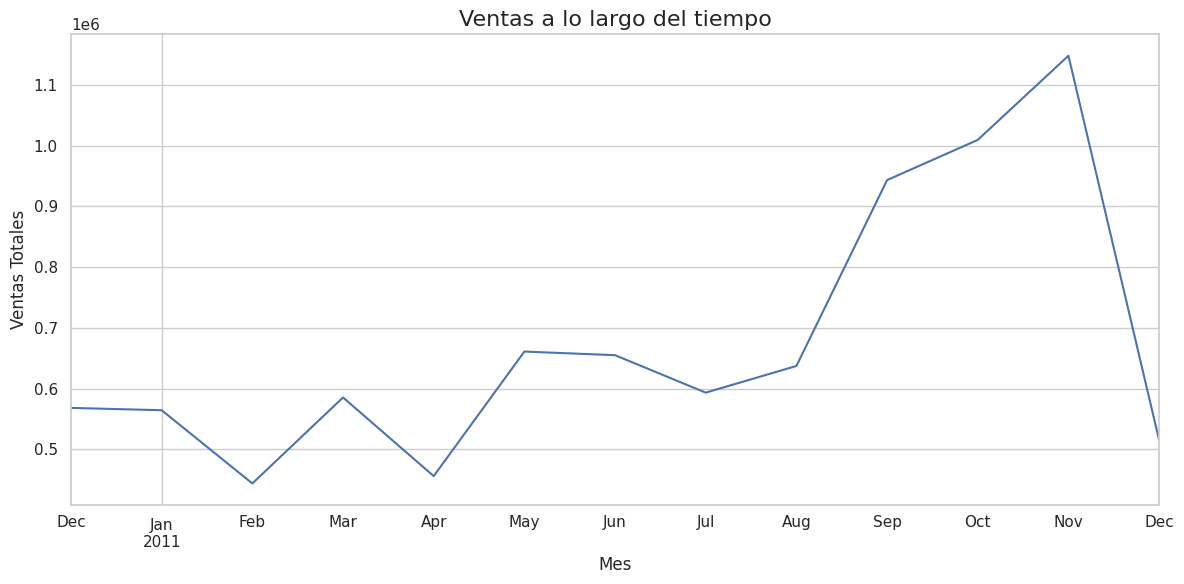

In [23]:
plt.figure(figsize=(12,6))

ventas_mes.plot()

plt.title("Ventas a lo largo del tiempo", fontsize=16)
plt.xlabel("Mes")
plt.ylabel("Ventas Totales")

plt.tight_layout()

plt.savefig("ventas_mes.png", dpi=300, bbox_inches='tight')

plt.show()

In [24]:
from google.colab import files
files.download("top_productos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
files.download("top_clientes.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files
files.download("ventas_mes.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>